# Random Forest vs XGBoost

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    roc_auc_score, 
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    roc_curve,
    confusion_matrix
)

In [22]:


# ============================================
# CARGAR MODELOS
# ============================================

# Cargar Random Forest
rf_model = joblib.load('../models/best_rf_model.pkl')

# Cargar XGBoost
xgb_model = joblib.load('../models/best_xgb_model.pkl')

# Cargar datos
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('../data/processed.csv')
X = df.drop('churn', axis=1)
y = df['churn']

# Split (igual que en training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:

# ============================================
# PREDICCIONES
# ============================================

# Random Forest
y_rf_pred = rf_model.predict(X_test)
y_rf_proba = rf_model.predict_proba(X_test)[:, 1]

# XGBoost
y_xgb_pred = xgb_model.predict(X_test)
y_xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

In [24]:

# ============================================
# COMPARACIÓN DE MÉTRICAS
# ============================================

print("="*70)
print("COMPARACIÓN: RANDOM FOREST vs XGBOOST")
print("="*70)

metrics_comparison = pd.DataFrame({
    'Métrica': ['ROC-AUC', 'F1-Score', 'Precision', 'Recall'],
    'Random Forest': [
        roc_auc_score(y_test, y_rf_proba),
        f1_score(y_test, y_rf_pred),
        precision_score(y_test, y_rf_pred),
        recall_score(y_test, y_rf_pred)
    ],
    'XGBoost': [
        roc_auc_score(y_test, y_xgb_proba),
        f1_score(y_test, y_xgb_pred),
        precision_score(y_test, y_xgb_pred),
        recall_score(y_test, y_xgb_pred)
    ]
})

print("\n" + metrics_comparison.to_string(index=False))

# Calcular diferencias
metrics_comparison['Diferencia'] = metrics_comparison['XGBoost'] - metrics_comparison['Random Forest']
metrics_comparison['Ganador'] = metrics_comparison['Diferencia'].apply(
    lambda x: 'XGBoost' if x > 0.01 else ('Empate' if abs(x) <= 0.01 else 'RF')
)

print("\n" + metrics_comparison[['Métrica', 'Diferencia', 'Ganador']].to_string(index=False))

COMPARACIÓN: RANDOM FOREST vs XGBOOST

  Métrica  Random Forest  XGBoost
  ROC-AUC       0.861779 0.866052
 F1-Score       0.618510 0.612740
Precision       0.572025 0.520619
   Recall       0.673219 0.744472

  Métrica  Diferencia Ganador
  ROC-AUC    0.004274  Empate
 F1-Score   -0.005770  Empate
Precision   -0.051406      RF
   Recall    0.071253 XGBoost


In [25]:
# ============================================
# CLASIFICACIÓN REPORT
# ============================================

print("\n" + "="*70)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*70)
print(classification_report(y_test, y_rf_pred, target_names=['No Churn', 'Churn']))

print("\n" + "="*70)
print("CLASSIFICATION REPORT - XGBOOST")
print("="*70)
print(classification_report(y_test, y_xgb_pred, target_names=['No Churn', 'Churn']))



CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.91      0.87      0.89      1593
       Churn       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000


CLASSIFICATION REPORT - XGBOOST
              precision    recall  f1-score   support

    No Churn       0.93      0.82      0.87      1593
       Churn       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



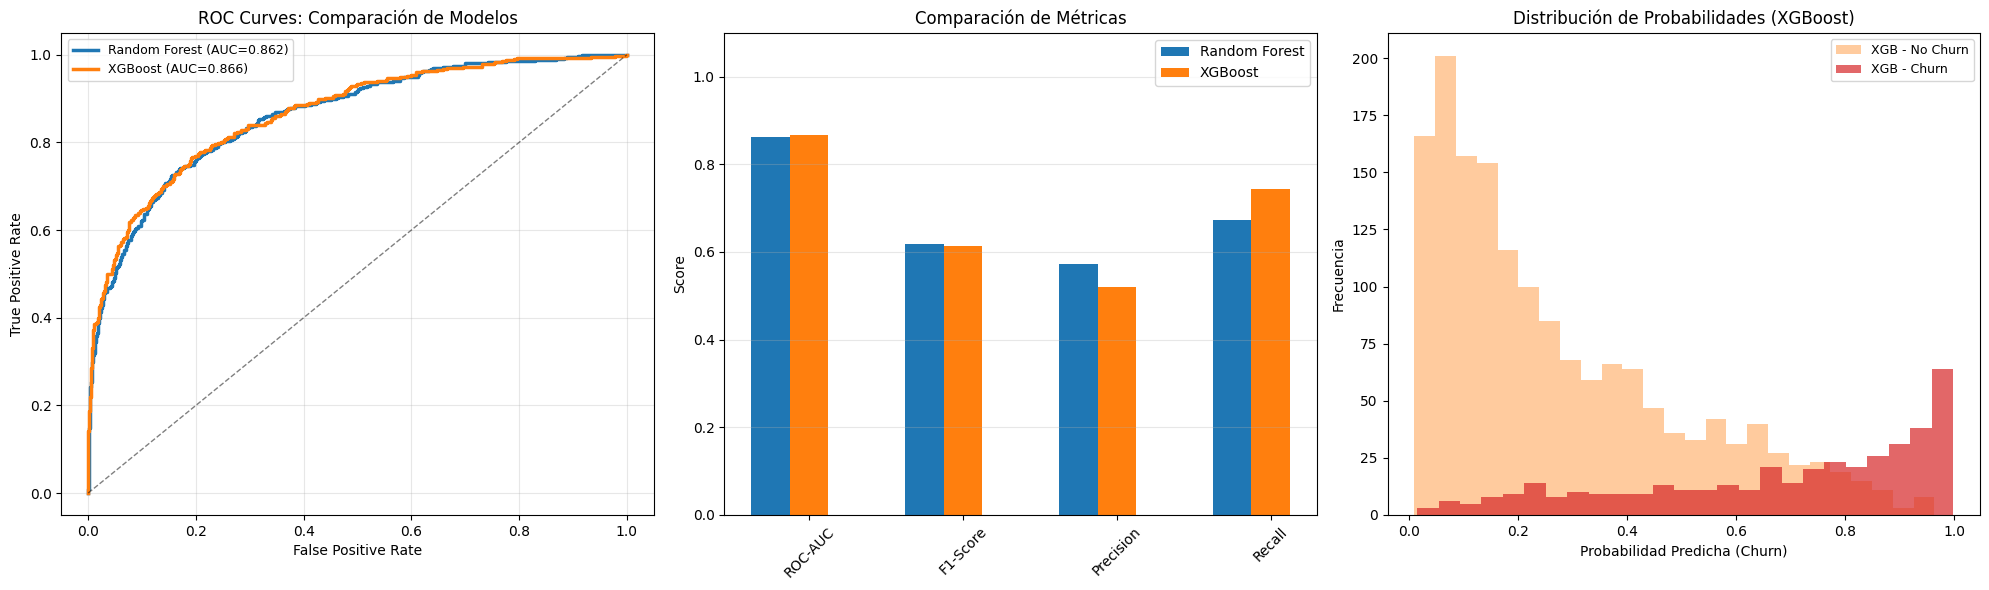

In [26]:
# ============================================
# VISUALIZACIONES 
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

# 1. ROC Curves Comparación
ax = axes[0] 
modelos = [
    (y_rf_proba, 'Random Forest', '#1f77b4'),
    (y_xgb_proba, 'XGBoost', '#ff7f0e'),
]

for y_proba, label, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{label} (AUC={auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Comparación de Modelos')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 2. Métrica Comparison Bar Plot
ax = axes[1] 
x = np.arange(len(metrics_comparison))
width = 0.25

ax.bar(x - width, metrics_comparison['Random Forest'], width, label='Random Forest', color='#1f77b4')
ax.bar(x, metrics_comparison['XGBoost'], width, label='XGBoost', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison['Métrica'], rotation=45) # Rotación para lectura
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1]) # Espacio extra para las etiquetas

# 3. Probabilidades Distribution
ax = axes[2] 
ax.hist(y_xgb_proba[y_test == 0], bins=25, alpha=0.4, label='XGB - No Churn', color='#ff7f0e')
ax.hist(y_xgb_proba[y_test == 1], bins=25, alpha=0.7, label='XGB - Churn', color='#d62728') 

ax.set_xlabel('Probabilidad Predicha (Churn)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Probabilidades (XGBoost)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=300, bbox_inches='tight')  
plt.show() # Añadido para ver la gráfica en el notebook

In [28]:
# ============================================
# RESUMEN
# ============================================
rf_roc = roc_auc_score(y_test, y_rf_proba)
xgb_roc = roc_auc_score(y_test, y_xgb_proba)
print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)

print(f"""
┌─ Random Forest ─────────────────┐
│  ROC-AUC: {roc_auc_score(y_test, y_rf_proba):.4f}
│  F1-Score: {f1_score(y_test, y_rf_pred):.4f}
└─────────────────────────────────┘

┌─ XGBoost ───────────────────────┐
│  ROC-AUC: {roc_auc_score(y_test, y_xgb_proba):.4f}
│  F1-Score: {f1_score(y_test, y_xgb_pred):.4f}
└─────────────────────────────────┘



Recomendación:
""")

if xgb_roc > rf_roc:
    print("  Mejor: XGBoost (usar para producción)")
else:
    print("  Mejor: Random Forest (usar para producción)")





RESUMEN FINAL

┌─ Random Forest ─────────────────┐
│  ROC-AUC: 0.8618
│  F1-Score: 0.6185
└─────────────────────────────────┘

┌─ XGBoost ───────────────────────┐
│  ROC-AUC: 0.8661
│  F1-Score: 0.6127
└─────────────────────────────────┘



Recomendación:

  Mejor: XGBoost (usar para producción)
